In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import joblib


In [2]:
df = pd.read_csv('../House_Rent_Dataset_TN_synthetic_text_1500_preprocessed.csv')
df.head()


,Rent,Posted On,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,...,Listing_Description,Amenities_Text,Landmarks_Text,Reviews_Text,Complaints_Text,Lease_Rules_Text,Inquiry_Text,Inspection_Notes_Text,Scam_Flag,Scam_Rationale
0,15000,2022-07-06,2,1100,1 out of 2,super area,medavakkam,chennai,semi-furnished,bachelors,...,2 bhk semi-furnished home of 1100 sq ft (super...,"rainwater harvesting, play area, solar lightin...",near college (3.3 km); near hospital (0.6 km);...,clean and well maintained building. | safe are...,not_applicable,no smoking inside the house. tenant must follo...,looking for a 2 bhk near medavakkam within inr...,flooring shows normal wear. bathrooms are clea...,no,not_applicable
1,6500,2022-05-21,2,1000,ground out of 1,super area,"urapakkam, vandalur r.f, gst road",chennai,semi-furnished,bachelors/family,...,2 bhk semi-furnished home of 1000 sq ft (super...,"visitor parking, cctv, power backup, club hous...",near market (3.5 km); near school (0.8 km); ne...,clean and well maintained building. | good wat...,listing photos did not match actual house.,security deposit is two months rent. no loud m...,"want to move in next month, budget around inr ...",flooring shows normal wear. good natural light...,yes,owner refused physical visit. | asked for paym...
2,90000,2022-05-20,3,2400,1 out of 3,carpet area,"r.a puram, mandaiveli",chennai,semi-furnished,bachelors/family,...,3 bhk semi-furnished home of 2400 sq ft (carpe...,"waste management, power backup, lift, fire saf...",near pharmacy (0.6 km); near church (0.6 km),good water supply and quiet neighborhood. | ma...,not_applicable,security deposit is two months rent. maintenan...,"want to move in next month, budget around inr ...",electrical fittings are working properly. floo...,no,not_applicable
3,200000,2022-07-10,3,3000,1 out of 1,super area,madras boat club road,chennai,furnished,family,...,3 bhk furnished home of 3000 sq ft (super area...,"security, play area, gym, maintenance staff, w...",near mosque (3.4 km); near atm (1.8 km),parking is convenient and secure. | spacious r...,not_applicable,maintenance charges are extra. pets allowed on...,"want to move in next month, budget around inr ...",walls need minor repainting. good natural ligh...,no,not_applicable
4,15000,2022-06-25,1,650,ground out of 2,carpet area,kambar colony,chennai,semi-furnished,bachelors/family,...,1 bhk semi-furnished home of 650 sq ft (carpet...,"maintenance staff, security, rainwater harvest...",near atm (3.5 km); near hospital (3.8 km); nea...,easy access to public transport. | maintenance...,not_applicable,pets allowed only with prior approval. no loud...,"need a semi-furnished home in chennai, prefer ...",bathrooms are clean and functional. walls need...,no,not_applicable


In [3]:
# Problem: Rental Price Segment Clustering
# Group houses into low, medium and high rental segments.

X = df[['Rent', 'Size', 'BHK', 'Bathroom']]
X.head()


,Rent,Size,BHK,Bathroom
0,15000,1100,2,2
1,6500,1000,2,2
2,90000,2400,3,3
3,200000,3000,3,4
4,15000,650,1,1


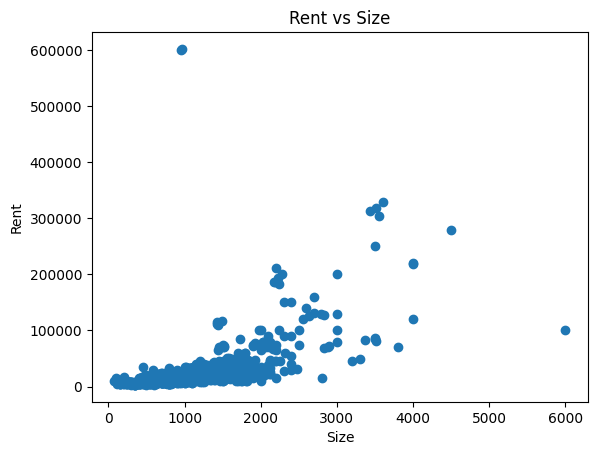

In [4]:
plt.scatter(df['Size'], df['Rent'])
plt.xlabel('Size')
plt.ylabel('Rent')
plt.title('Rent vs Size')
plt.show()


In [5]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

model = KMeans(n_clusters=3, random_state=42)
y_predicted = model.fit_predict(X_scaled)

y_predicted


array([0, 0, 2, ..., 0, 1, 1], shape=(1500,), dtype=int32)

In [6]:
df['Cluster'] = y_predicted
df[['Rent', 'Size', 'BHK', 'Bathroom', 'Cluster']].head()


,Rent,Size,BHK,Bathroom,Cluster
0,15000,1100,2,2,0
1,6500,1000,2,2,0
2,90000,2400,3,3,2
3,200000,3000,3,4,2
4,15000,650,1,1,1


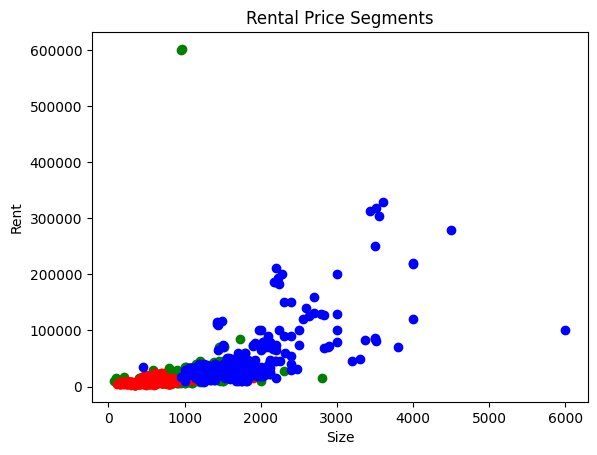

In [7]:
df1 = df[df.Cluster == 0]
df2 = df[df.Cluster == 1]
df3 = df[df.Cluster == 2]

plt.scatter(df1['Size'], df1['Rent'], color='green')
plt.scatter(df2['Size'], df2['Rent'], color='red')
plt.scatter(df3['Size'], df3['Rent'], color='blue')

plt.xlabel('Size')
plt.ylabel('Rent')
plt.title('Rental Price Segments')
plt.show()


In [8]:
df.groupby('Cluster')[['Rent', 'Size', 'BHK', 'Bathroom']].mean()


,Rent,Size,BHK,Bathroom
Cluster,,,,
0,17247.074627,973.461538,2.165327,2.010333
1,9270.651685,570.775281,1.252809,1.047753
2,54740.564103,1845.978022,3.168498,3.249084


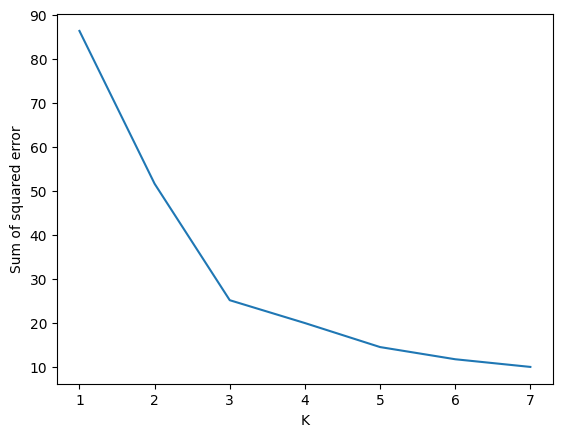

In [9]:
# Elbow method
sse = []
k_rng = range(1, 8)

for k in k_rng:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng, sse)
plt.show()


In [10]:
# Predict segment for a new house
# Rent = 15000, Size = 1000, BHK = 2, Bathroom = 2
new_house = [[15000, 1000, 2, 2]]
new_house_scaled = scaler.transform(new_house)
model.predict(new_house_scaled)


c:\Users\dell_\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([0], dtype=int32)

In [11]:
joblib.dump(model, 'house_rent_kmeans_rental_price_segments.pkl')


['house_rent_kmeans_rental_price_segments.pkl']